<a href="https://colab.research.google.com/github/KowshiqKatta/Generative-AI/blob/main/LangGraph/Sequential_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain

In [ ]:
!pip install langgraph

In [ ]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 1.2 MB/s eta 0:00:00


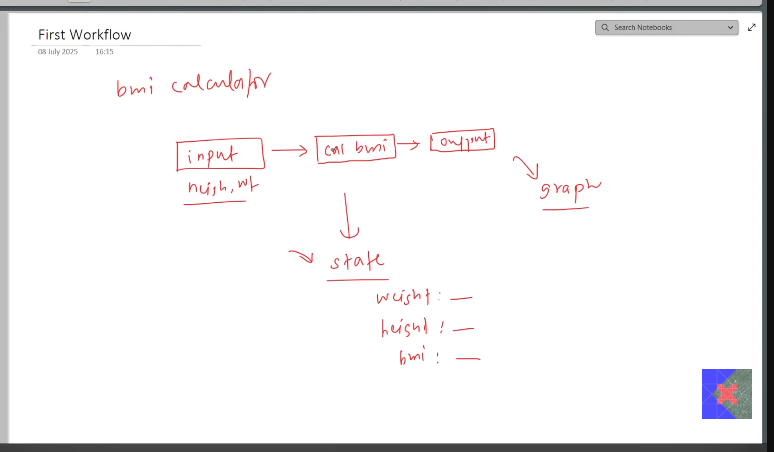

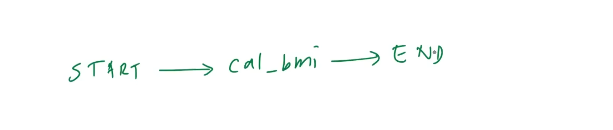

In [ ]:
# define state

from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float
  category: str


In [ ]:
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state['weight_kg']
  height = state['height_m']
  bmi = weight / (height ** 2)
  state['bmi'] = round(bmi, 2)
  return state


In [ ]:
def label_bmi(state: BMIState) -> BMIState:
  bmi = state['bmi']
  if bmi < 18.5:
    state['category'] = 'Underweight'
  elif bmi < 25:
    state['category'] = 'Normal'
  elif bmi < 30:
    state['category'] = 'Overweight'
  else:
    state['category'] = 'Obese'
  return state

In [ ]:
# define graph
graph = StateGraph(BMIState)

# add nodes
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile
workflow = graph.compile()

In [ ]:
# execute

initial_state = {'weight_kg': 80, 'height_m': 1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


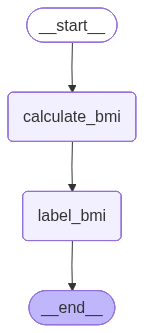

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

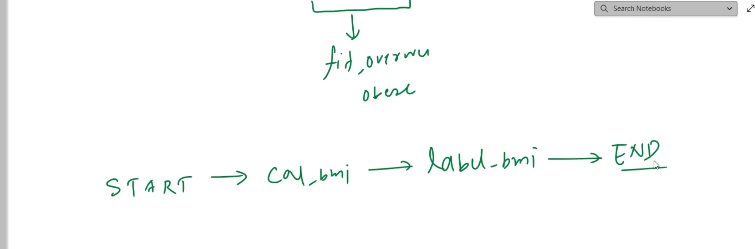

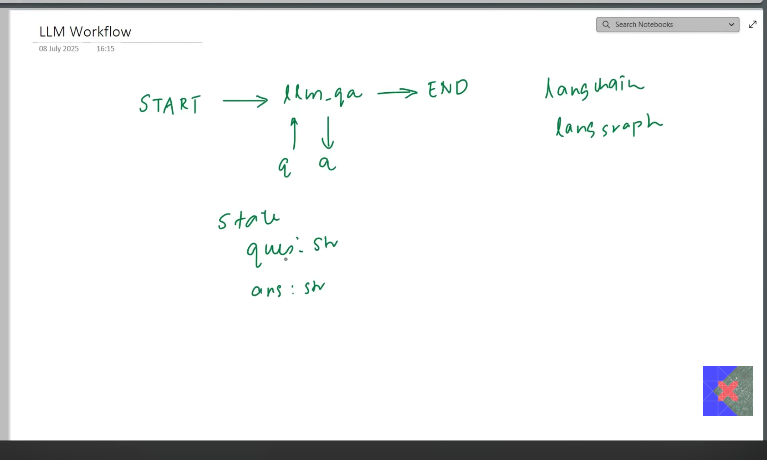

In [ ]:
from langchain_openai import ChatOpenAI

### Setting your OpenAI API key securely in Colab

1.  **Open the Secrets Manager**: Click on the "🔑 Secrets" icon in the left sidebar of your Colab notebook.
2.  **Add a new secret**: Click on "+ New secret" and enter `OPENAI_API_KEY` as the Name and your OpenAI API key as the Value.
3.  **Enable access**: Make sure to toggle on "Notebook access" for this secret.

Once set, you can access it in your code like this:

In [ ]:
import os
from google.colab import userdata

# Retrieve the API key from Colab's Secret Manager
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

# Now you can initialize your ChatOpenAI model without passing the key directly
model = ChatOpenAI()

In [ ]:
class LLMState(TypedDict):
  question: str
  answer: str

In [ ]:
def llm_qa(state: LLMState) -> LLMState:

  # extract the question
  question = state['question']

  # form a prompt
  prompt = f'Answer the following question {question}'

  # ask that question to the LLM
  answer = model.invoke(prompt).content

  # update the answer in the state
  state['answer'] = answer

  return state

In [ ]:
# create graph

graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

In [ ]:
initial_state = {'question': 'How far is moon from the earth?'}

final_state = workflow.invoke(initial_state)

print(final_state['answer'])

The average distance from the moon to the earth is about 238,855 miles (384,400 kilometers).


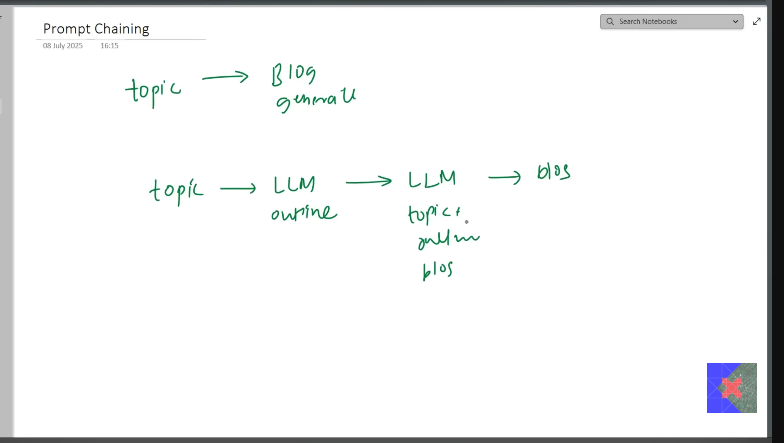

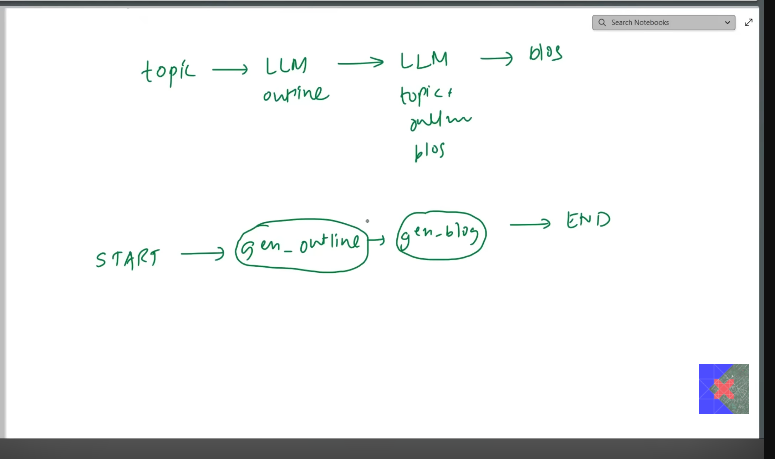

In [ ]:
class BlogState(TypedDict):

  title: str
  outline: str
  content: str

In [ ]:
def create_outline(state: BlogState) -> BlogState:

  # fetch title

  title = state['title']

  # call llm gen outline

  prompt = f'Generate an detailed outline for a blog on the topic - {title}'
  outline = model.invoke(prompt).content

  # update state
  state['outline'] = outline

  return state

In [ ]:
def create_blog(state: BlogState) -> BlogState:
  title = state['title']
  outline = state['outline']

  prompt = f'write a detailed blog on the title - {title} using the following outline \n {outline}'
  content = model.invoke(prompt).content

  state['content'] = content

  return state


In [ ]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [ ]:
initial_state = {
    'title': 'Rise of AI in India'
}

final_state = workflow.invoke(initial_state)

print(final_state['outline'])

I. Introduction
    A. Definition of Artificial Intelligence (AI)
    B. Overview of AI technology
    C. Significance of AI in India
  
II. History of AI in India
    A. Development of AI technology in India
    B. Major AI research centers in India
    C. Government initiatives supporting AI development
    D. Role of Indian tech companies in AI advancements
  
III. Current State of AI in India
    A. Applications of AI in various industries in India
    B. AI startups and organizations in India
    C. Challenges faced by AI implementation in India
    D. Opportunities for growth and innovation in AI technology in India
  
IV. Rise of AI in India
    A. Factors contributing to the growth of AI in India
    B. Leading AI projects and advancements in India
    C. Impact of AI on Indian society and economy
    D. Collaboration between Indian and international AI companies
  
V. Future of AI in India
    A. Potential trends and developments in AI technology in India
    B. Government pol

In [ ]:
print(final_state['content'])

Artificial Intelligence (AI) has become a buzzword in today's highly technological world, transforming the way we live, work, and interact with each other. AI is the simulation of human intelligence processes by machines, including learning, reasoning, problem-solving, perception, and language understanding. In India, the rise of AI technology is gaining momentum, with various industries and organizations embracing its capabilities to drive innovation and efficiency.

History of AI in India:
India has a long history of research and development in the field of AI. The country has several renowned AI research centers, such as the Indian Institute of Science in Bangalore, the Indian Institutes of Technology (IITs) in Delhi, Bombay, and Madras, and the Centre for Artificial Intelligence and Robotics (CAIR) in Bangalore. These centers have been at the forefront of AI advancements in India, conducting cutting-edge research and development in various AI applications.

The Indian government ha